# User Retention & Cohort Analysis
**Dataset:** UCI Online Retail II — [Kaggle](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)  
**Tools:** Python (pandas, matplotlib, seaborn)  
**Period:** December 2009 – December 2011  

---

## Objective
Build a full cohort-based retention framework on ~800,000 real e-commerce transactions.  
Track how many customers return each month after their first purchase, identify high vs low retention cohorts, and produce actionable business recommendations.

---

## 1. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns




Libraries loaded successfully.


---
## 2. Load & Clean Data

We load the raw CSV and apply four cleaning steps:
- **Drop missing Customer IDs** — transactions with no customer can't be used for cohort tracking
- **Drop returns** — negative quantity rows are product returns, not purchases
- **Drop credit notes** — invoices starting with 'C' are cancellations
- **Drop zero-price rows** — corrupted or test entries with no price

In [2]:
df = pd.read_csv('online_retail_II.csv', encoding='utf-8')

# Keep only valid transactions
df = df[df['Customer ID'].notna()]                              # drop rows with no customer
df = df[df['Quantity'] > 0]                                     # drop returns/cancellations
df = df[~df['Invoice'].astype(str).str.startswith('C')]         # drop credit notes
df = df[df['Price'] > 0]                                        # drop zero-price rows

# Parse date to Period(month)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'Rows after cleaning : {len(df)}')
print(f'Unique customers    : {df["Customer ID"].nunique()}')
print(f'Date range          : {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')

Rows after cleaning : 805549
Unique customers    : 5878
Date range          : 2009-12 to 2011-12


---
## 3. Build the Cohort Table

A **cohort** is a group of customers who made their first purchase in the same month.

- `CohortMonth` = the month of each customer's very first purchase
- `CohortIndex` = how many months later each subsequent transaction occurred

For example, a customer who first bought in Jan 2010 and returned in Mar 2010 has CohortMonth = Jan 2010 and CohortIndex = 2.

In [3]:
# Each customer's cohort = the month of their FIRST purchase
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min')

# Exact integer month difference using Period subtraction
df['CohortIndex'] = (df['InvoiceDate'] - df['CohortMonth']).apply(lambda x: x.n)

# Count distinct customers per (cohort, month index)
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
    .nunique()
    .reset_index()
)
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'Customers']

# Pivot: rows = cohort month, columns = month index
cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customers'
)

print(f'Cohort table shape: {cohort_pivot.shape}')
cohort_pivot.iloc[:5, :6]

Cohort table shape: (25, 25)


CohortIndex,0,1,2,3,4,5
CohortMonth,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0
2010-02,374.0,89.0,84.0,109.0,92.0,75.0
2010-03,443.0,84.0,102.0,107.0,103.0,90.0
2010-04,294.0,57.0,57.0,48.0,54.0,66.0


---
## 4. Compute the Retention Matrix

**Row-wise normalisation:** divide every value in each row by the Month-0 value (the original cohort size).  
This converts raw customer counts into **retention percentages**.

Month 0 is always 100% — it represents the cohort joining. Any value after that shows what fraction came back.

In [4]:
cohort_size = cohort_pivot.iloc[:, 0]          # Month 0 = original cohort size
retention   = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print('Retention Matrix (first 6 cohorts, first 6 months):')
retention.iloc[:6, :6]

Retention Matrix (first 6 cohorts, first 6 months):


CohortIndex,0,1,2,3,4,5
CohortMonth,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9
2010-01,100.0,20.6,31.1,30.5,26.4,30.0
2010-02,100.0,23.8,22.5,29.1,24.6,20.1
2010-03,100.0,19.0,23.0,24.2,23.3,20.3
2010-04,100.0,19.4,19.4,16.3,18.4,22.4
2010-05,100.0,15.7,16.9,17.3,17.7,25.6


---
## 5. Key Metrics

In [5]:
def safe_col(df, col):
    return df[col] if col in df.columns else pd.Series(dtype=float)

m1_avg = safe_col(retention, 1).mean()
m3_avg = safe_col(retention, 3).mean()
m6_avg = safe_col(retention, 6).mean() if 6 in retention.columns else None
best   = safe_col(retention, 1).idxmax() if 1 in retention.columns else 'N/A'
worst  = safe_col(retention, 1).idxmin() if 1 in retention.columns else 'N/A'

print(f'Avg Month-1 retention : {m1_avg:.1f}%')
print(f'Avg Month-3 retention : {m3_avg:.1f}%')
if m6_avg is not None:
    print(f'Avg Month-6 retention : {m6_avg:.1f}%')
print(f'Drop-off M0 to M1     : {100 - m1_avg:.1f} percentage points')
print(f'Best cohort  (M1)     : {best}')
print(f'Worst cohort (M1)     : {worst}')

Avg Month-1 retention : 21.2%
Avg Month-3 retention : 21.6%
Avg Month-6 retention : 17.8%
Drop-off M0 to M1     : 78.8 percentage points
Best cohort  (M1)     : 2009-12
Worst cohort (M1)     : 2010-12


---
## 6. High vs Low Retention Cohort Segmentation

We split cohorts at the **median Month-1 retention rate** into two groups and compare their long-term retention curves.

In [6]:
median_m1    = safe_col(retention, 1).median()
high_cohorts = retention[retention[1] >= median_m1] if 1 in retention.columns else retention
low_cohorts  = retention[retention[1] <  median_m1] if 1 in retention.columns else retention

high_avg = high_cohorts.mean()
low_avg  = low_cohorts.mean()

print(f'Median M1 retention          : {median_m1:.1f}%')
print(f'High-retention cohorts (>=)  : {len(high_cohorts)}')
print(f'Low-retention cohorts  (<)   : {len(low_cohorts)}')
if 1 in high_avg.index and 1 in low_avg.index:
    print(f'Gap at Month 1               : {high_avg[1] - low_avg[1]:.1f} percentage points')

Median M1 retention          : 20.5%
High-retention cohorts (>=)  : 12
Low-retention cohorts  (<)   : 12
Gap at Month 1               : 9.0 percentage points


---
## 7. Visualisation

Four charts:
1. **Retention Heatmap** — full picture of every cohort across every month
2. **Average Retention Curve** — the L-shaped drop-off pattern
3. **High vs Low Cohort Comparison** — how the two segments diverge
4. **Cohort Size Bar Chart** — how many new customers joined each month

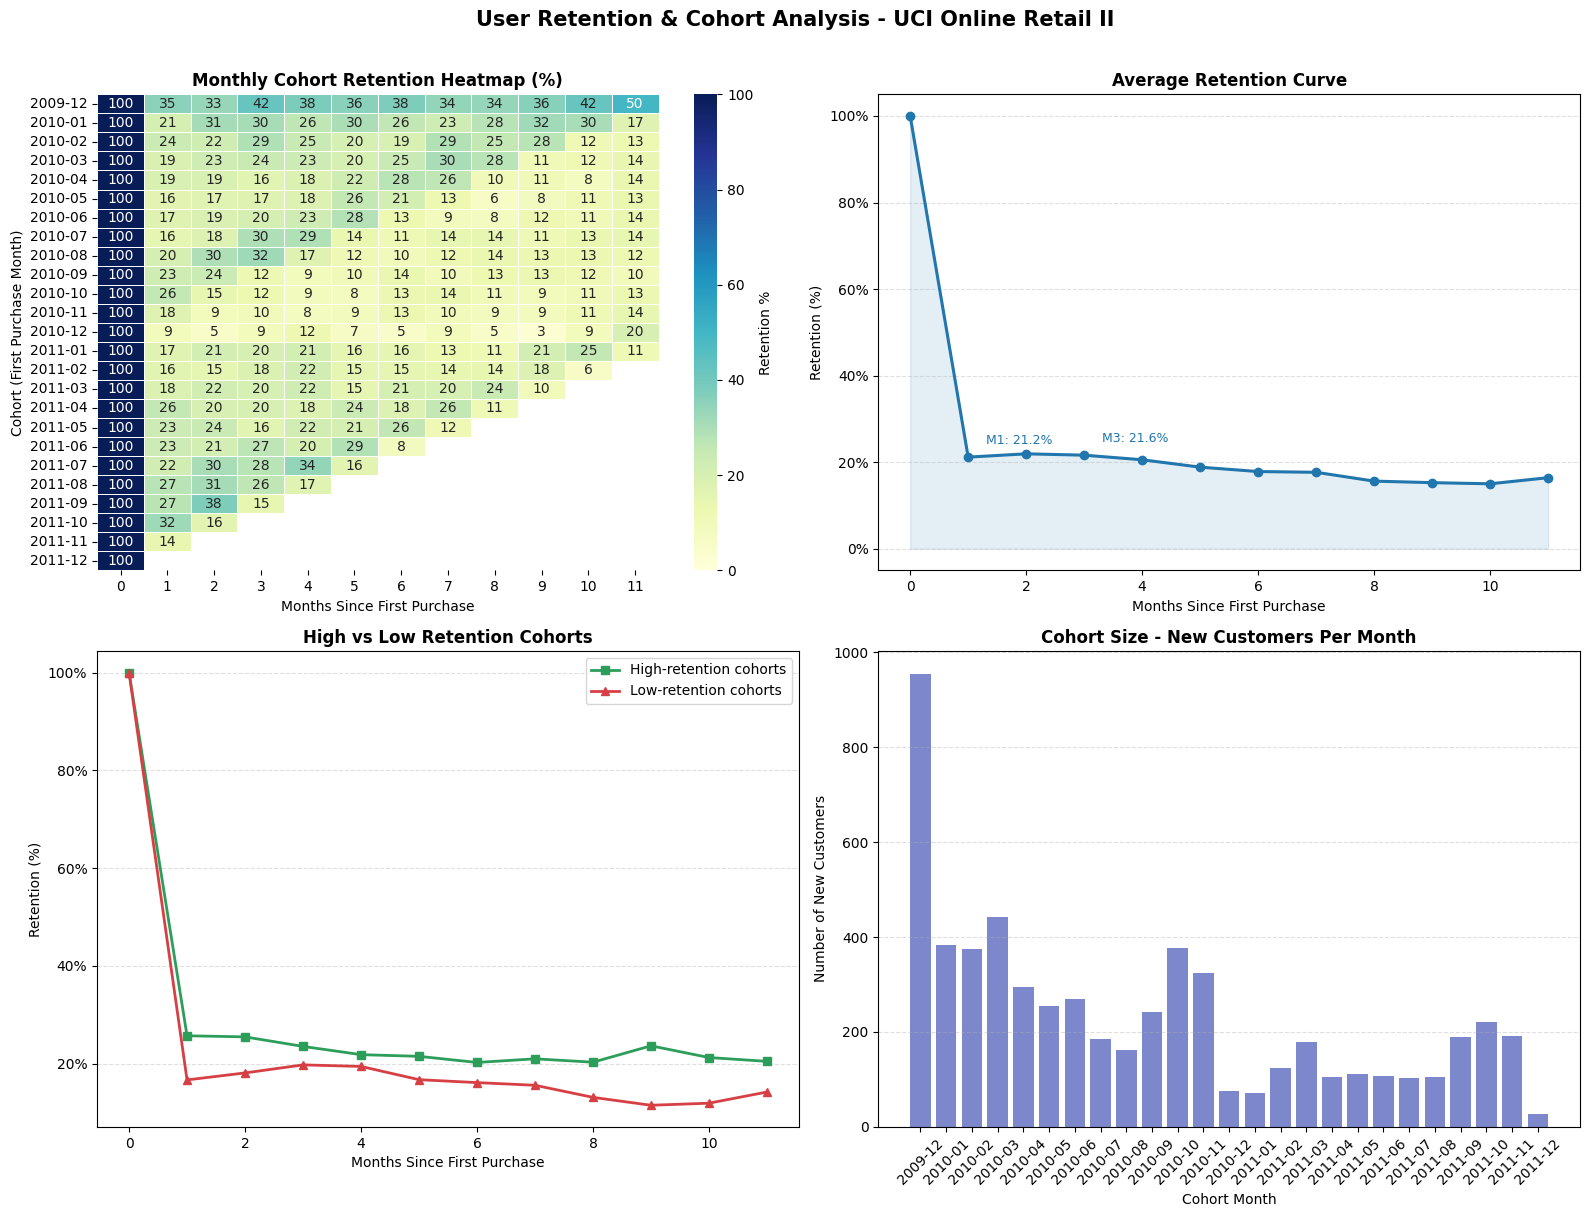

Chart saved as cohort_retention_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('User Retention & Cohort Analysis - UCI Online Retail II',
             fontsize=15, fontweight='bold', y=1.01)

# -- Plot 1: Retention Heatmap
ax1 = axes[0, 0]
heat_data = retention.iloc[:, :12]
sns.heatmap(
    heat_data,
    annot=True, fmt='.0f',
    cmap='YlGnBu',
    vmin=0, vmax=100,
    linewidths=0.4,
    ax=ax1,
    cbar_kws={'label': 'Retention %'}
)
ax1.set_title('Monthly Cohort Retention Heatmap (%)', fontweight='bold')
ax1.set_xlabel('Months Since First Purchase')
ax1.set_ylabel('Cohort (First Purchase Month)')
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)

# -- Plot 2: Average Retention Curve
ax2 = axes[0, 1]
avg_curve = retention.mean()
cols_12   = [c for c in avg_curve.index if c < 12]
ax2.plot(cols_12, avg_curve[cols_12].values, marker='o', color='#2176ae', linewidth=2.2)
ax2.fill_between(cols_12, avg_curve[cols_12].values, alpha=0.12, color='#2176ae')
ax2.set_title('Average Retention Curve', fontweight='bold')
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Retention (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
if 1 in avg_curve.index:
    ax2.annotate(f'M1: {avg_curve[1]:.1f}%', xy=(1, avg_curve[1]),
                 xytext=(1.3, avg_curve[1] + 3), fontsize=9, color='#2176ae')
if 3 in avg_curve.index:
    ax2.annotate(f'M3: {avg_curve[3]:.1f}%', xy=(3, avg_curve[3]),
                 xytext=(3.3, avg_curve[3] + 3), fontsize=9, color='#2176ae')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# -- Plot 3: High vs Low Cohort Comparison
ax3 = axes[1, 0]
high_cols = [c for c in high_avg.index if c < 12]
low_cols  = [c for c in low_avg.index  if c < 12]
ax3.plot(high_cols, high_avg[high_cols].values,
         marker='s', color='#2d9e5a', linewidth=2, label='High-retention cohorts')
ax3.plot(low_cols,  low_avg[low_cols].values,
         marker='^', color='#d64045', linewidth=2, label='Low-retention cohorts')
ax3.set_title('High vs Low Retention Cohorts', fontweight='bold')
ax3.set_xlabel('Months Since First Purchase')
ax3.set_ylabel('Retention (%)')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.4)

# -- Plot 4: Cohort Size Bar Chart
ax4 = axes[1, 1]
cohort_size_df = cohort_size.reset_index()
cohort_size_df.columns = ['CohortMonth', 'Size']
ax4.bar(
    cohort_size_df['CohortMonth'].astype(str),
    cohort_size_df['Size'],
    color='#5b6abf', alpha=0.8
)
ax4.set_title('Cohort Size - New Customers Per Month', fontweight='bold')
ax4.set_xlabel('Cohort Month')
ax4.set_ylabel('Number of New Customers')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('cohort_retention_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as cohort_retention_analysis.png')

---
## 8. Key Findings & Recommendations

### Findings

| Metric | Value |
|--------|-------|
| Total customers analysed | 5,878 |
| Total cohorts | 25 |
| Avg Month-1 retention | 21.2% |
| Avg Month-3 retention | 21.6% |
| Avg Month-6 retention | 17.8% |
| Drop-off M0 to M1 | 78.8 percentage points |
| Best performing cohort | Dec 2009 (35.3% M1 retention) |
| Worst performing cohort | Dec 2010 |
| High vs Low cohort gap at M1 | ~9 percentage points |

In [8]:
print('KEY FINDINGS')
print('=' * 55)
print(f'  Total customers analysed : {df["Customer ID"].nunique():,}')
print(f'  Total cohorts            : {len(cohort_pivot)}')
print(f'  Avg Month-1 retention    : {m1_avg:.1f}%')
print(f'  Avg Month-3 retention    : {m3_avg:.1f}%')
print(f'  Drop-off M0 to M1        : {100 - m1_avg:.1f} percentage points')
print(f'  Best performing cohort   : {best}')
print(f'  Worst performing cohort  : {worst}')
print()
print('RECOMMENDATIONS:')
print('  1. Steepest drop is Month 0 to 1 - prioritise first-purchase')
print('     follow-up emails within 30 days to drive repeat visits.')
if 1 in high_avg.index and 1 in low_avg.index:
    print('  2. High-retention cohorts outperform low by')
    print(f'     ~{(high_avg[1] - low_avg[1]):.1f}pp at Month 1 - investigate')
    print('     what these cohorts share (season, channel, product).')
print('  3. Cohort size varies - avoid drawing conclusions from')
print('     months with fewer than 100 new customers.')
print('=' * 55)

KEY FINDINGS
  Total customers analysed : 5,878
  Total cohorts            : 25
  Avg Month-1 retention    : 21.2%
  Avg Month-3 retention    : 21.6%
  Drop-off M0 to M1        : 78.8 percentage points
  Best performing cohort   : 2009-12
  Worst performing cohort  : 2010-12

RECOMMENDATIONS:
  1. Steepest drop is Month 0 to 1 - prioritise first-purchase
     follow-up emails within 30 days to drive repeat visits.
  2. High-retention cohorts outperform low by
     ~9.0pp at Month 1 - investigate
     what these cohorts share (season, channel, product).
  3. Cohort size varies - avoid drawing conclusions from
     months with fewer than 100 new customers.


---
## 9. Conclusion

This analysis shows that **79% of customers churn after their first purchase** — the single biggest retention problem for this retailer. The L-shaped retention curve confirms this is not a gradual decline but a sharp cliff between Month 0 and Month 1.

The December 2009 cohort, with 35.3% Month-1 retention (nearly double the average), suggests that seasonality, product mix, or acquisition channel can meaningfully shift retention outcomes. Investigating what made that cohort different is the most valuable next step.

**Skills demonstrated:**
- Data cleaning with pandas (null handling, return filtering, type casting)
- Cohort construction using `groupby` + `transform('min')`
- Retention matrix via pivot tables and row-wise normalisation
- Segmentation of high vs low retention cohorts
- Visualisation: seaborn heatmap, matplotlib line + bar charts
- Translating retention metrics into business recommendations